# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [2]:
monthly_count = df['count'].resample('ME').sum()


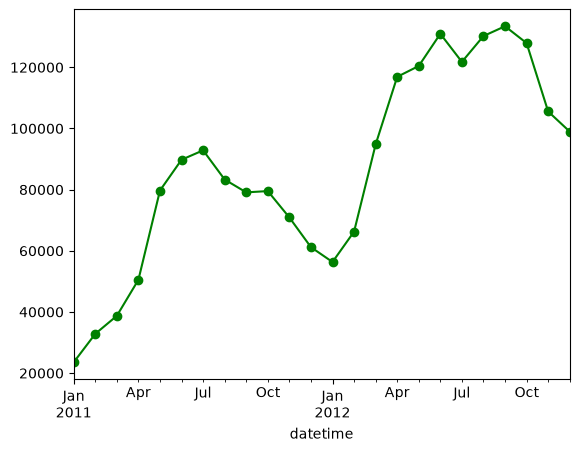

In [3]:
#using pandas for visualization

monthly_count.plot(
     marker="o",
    color="green"
    );

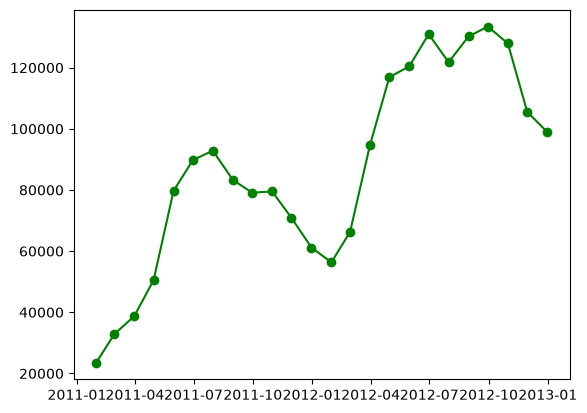

In [4]:
plt.plot(monthly_count, "o-", color="g");

самі графіки візуально ідентичні за винятком формату позначок осі ОХ: на графіку pandas позначки більш компактні та краще сприймаються.
а на графіку matplotlib мені подобається те, що сам графік не доторкається бічних границь та немає за замовченням піддпису "datetime", який, як на мене, перевантажує графік (і так з позначок осі ОХ зрозуміло, що там відкладено)

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [5]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

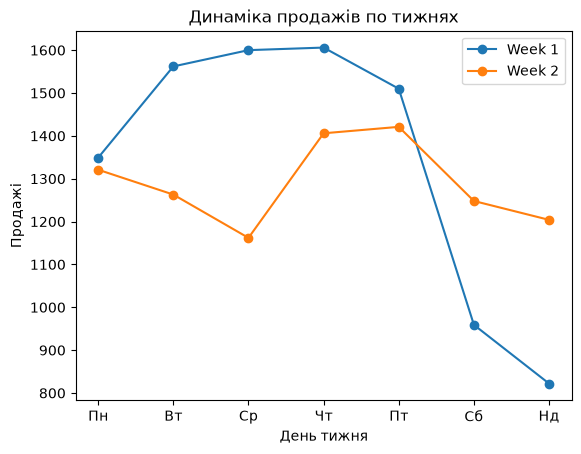

In [6]:
plt.plot(days, sales_week1,'o-', label="Week 1")
plt.plot(days, sales_week2,'o-', label="Week 2")
plt.title("Динаміка продажів по тижнях")
plt.xlabel('День тижня')
plt.ylabel('Продажі')
plt.xticks(days, ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'])
plt.legend()

plt.show()

Судячи з графіку, в тижні 2 проодажі були стабільніше, бо не було такого різкого падіння продажів на вихідні, як тижні 1.
хоча продажі в будні на тижні 1 були вищими, ніж на тижні 2.

Для перевірки стабільності продаж кожного тижня необхідно визначити розкид даних. 
Це можна зробити обчисливши такі метрики:
1) стандартне відхилення;
2) коефіціент варіації;
3) діапазон значень (max-min)
Стабільнішій тиждень буде мати менші показники в усіх 3 метриках.

Як видно з розрахунків внизу, стабільнішій є 2й тиждень.


In [7]:
# стандартне відхилення

print(f'Week 1 std = {np.std(sales_week1)}, Week 2 std = {np.std(sales_week2)}')

Week 1 std = 299.99857142517004, Week 2 std = 90.9060964256355


In [8]:
# коефіціент варіації;

cv_w1 = round(np.std(sales_week1)/np.mean(sales_week1)*100,2)
cv_w2 = round(np.std(sales_week2)/np.mean(sales_week2)*100,2)

print(f'Week 1 CV = {cv_w1}%, Week 2 CV = {cv_w2}%')


Week 1 CV = 22.32%, Week 2 CV = 7.05%


In [9]:
# діапазон значень (max-min)

w1_range = np.max(sales_week1)-np.min(sales_week1)
w2_range = np.max(sales_week2)-np.min(sales_week2)

print(f'Week 1 range = {w1_range}, Week 2 range = {w2_range}')

Week 1 range = 784, Week 2 range = 259


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [10]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'month',
       'hour', 'weekday', 'weekday_num', 'week', 'year', 'day'],
      dtype='str')

In [11]:
# середня температура помісячно
# av_temp = df['temp'].resample('ME').mean()
av_temp = df.groupby(['month'])['temp'].mean() 
av_temp.head(2)

month
1     9.840000
2    11.798535
Name: temp, dtype: float64

In [12]:
df['quarter'] = df.index.quarter
av_count_by_quarter = df.groupby(['quarter'])['count'].mean() # середня годинна кількість оренд за кварталами
av_count_by_quarter
# df['quarter'].head()

quarter
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: count, dtype: float64

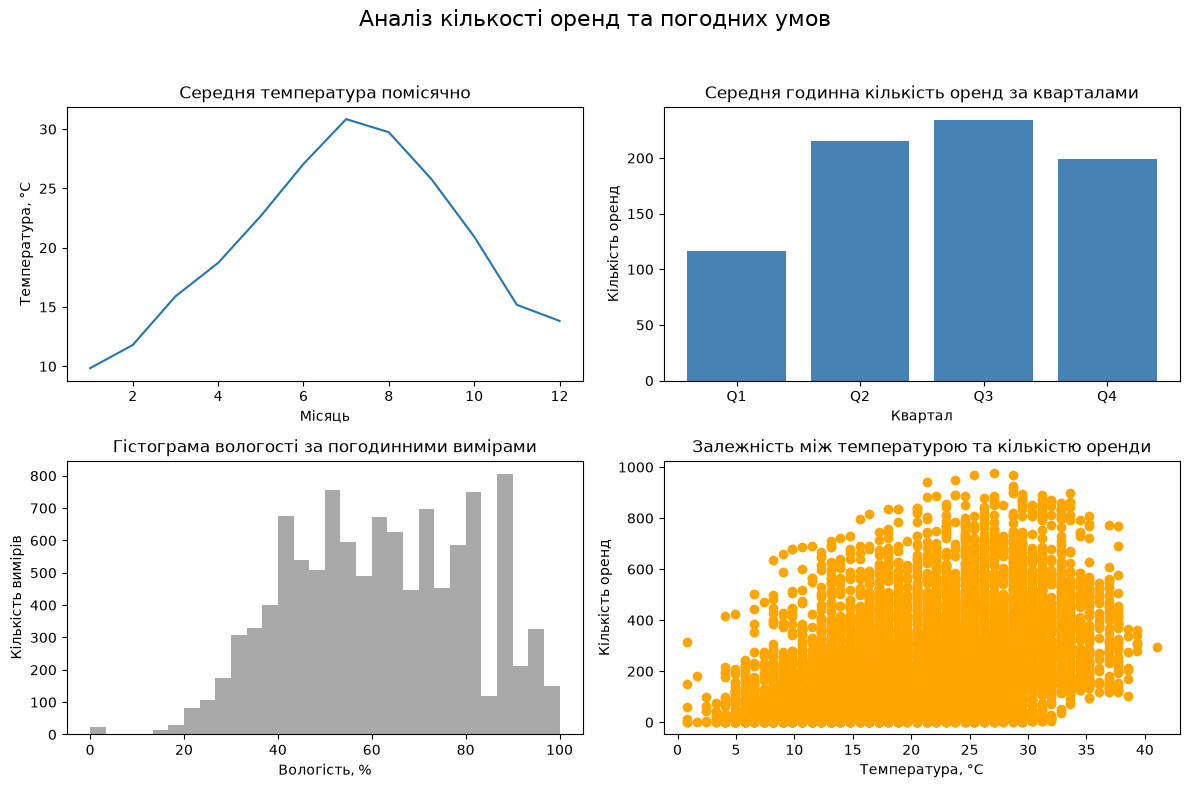

In [13]:
plt.figure(figsize=(12,8))

# Лінійний графік
plt.subplot(2,2,1)
plt.plot(av_temp)
plt.title('Cередня температура помісячно')
plt.ylabel('Температура, °C')
plt.xlabel('Місяць')
    
# Стовпчикова діаграма
plt.subplot(2,2,2)
plt.bar(av_count_by_quarter.index,av_count_by_quarter.values,color='steelblue')
plt.title('Середня годинна кількість оренд за кварталами')
plt.ylabel('Кількість оренд')
plt.xlabel('Квартал')
plt.xticks(av_count_by_quarter.index, [f'Q{q}' for q in av_count_by_quarter.index])

# Гістограма
plt.subplot(2,2,3)
plt.hist(df.humidity, bins=30, color='darkgrey')
plt.title('Гістограма вологості за погодинними вимірами')
plt.xlabel('Вологість, %')
plt.ylabel('Кількість вимірів')

# Scatter plot 
plt.subplot(2,2,4)
plt.title('Залежність між температурою та кількістю оренди')
plt.scatter(x=df.temp, y=df['count'], c='orange')
plt.xlabel('Температура, °C')
plt.ylabel('Кількість оренд')

plt.suptitle('Аналіз кількості оренд та погодних умов', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

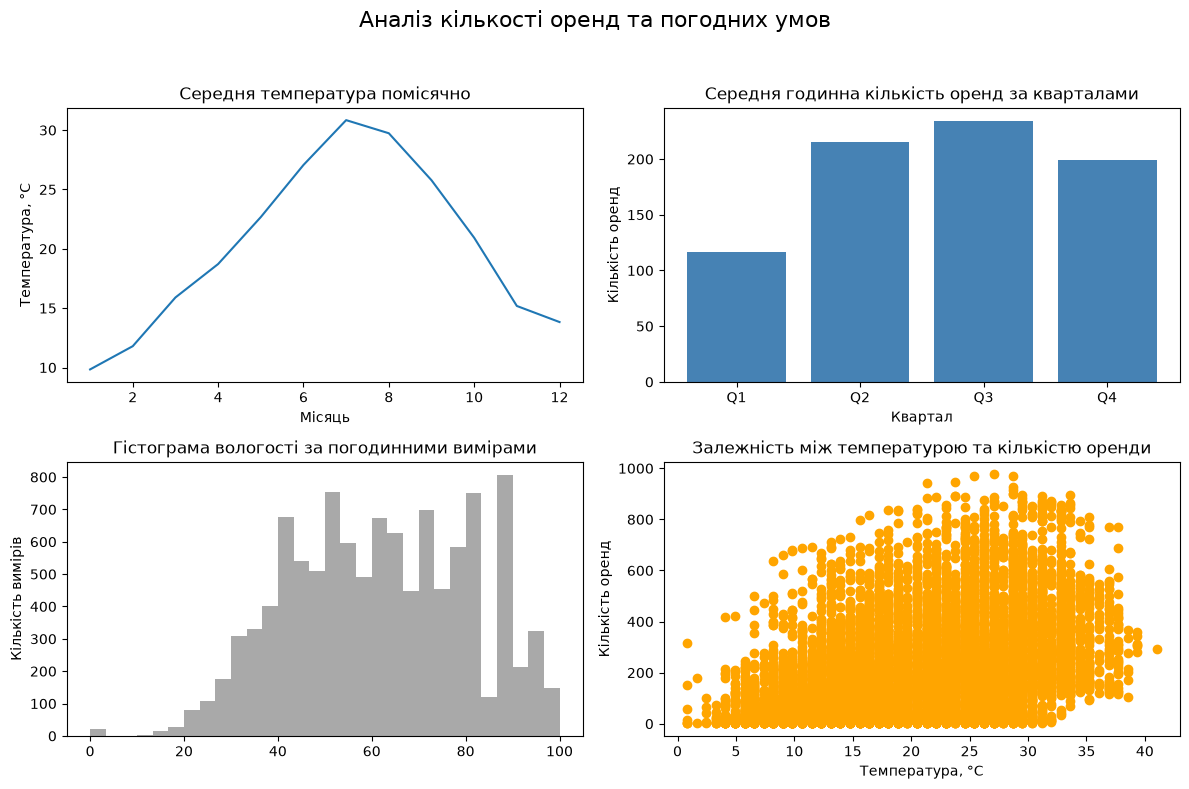

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Лінійний графік
ax[0, 0].plot(av_temp)
ax[0, 0].set_title('Cередня температура помісячно')
ax[0, 0].set_ylabel('Температура, °C')
ax[0, 0].set_xlabel('Місяць')

# Стовпчикова діаграма
ax[0, 1].bar(av_count_by_quarter.index,av_count_by_quarter.values,color='steelblue')
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами')
ax[0, 1].set_ylabel('Кількість оренд')
ax[0, 1].set_xlabel('Квартал')
ax[0,1].set_xticks(av_count_by_quarter.index, [f'Q{q}' for q in av_count_by_quarter.index])


# Гістограма
ax[1, 0].hist(df.humidity, bins=30, color='darkgrey')
ax[1, 0].set_title('Гістограма вологості за погодинними вимірами')
ax[1, 0].set_ylabel('Вологість, %')
ax[1, 0].set_ylabel('Кількість вимірів')

# Scatter plot 

ax[1, 1].set_title('Залежність між температурою та кількістю оренди')
ax[1, 1].scatter(x=df.temp, y=df['count'], c='orange')
ax[1, 1].set_xlabel('Температура, °C')
ax[1, 1].set_ylabel('Кількість оренд')

plt.suptitle('Аналіз кількості оренд та погодних умов', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?